# Multi-omics Demonstration with Fair Data Cube (FDCube) and WikiPathways

This notebook outlines the steps to map the SARS-CoV-2 innate immunity evasion and cell-specific immune response (WP5039) pathway from WikiPathways to multi-omics data from the FDC-TWOC example using Bridge DB. The FDC-TWOC example demonstrates onboarding metadata to the FDP, connecting it to a triple store endpoint, and using SPARQL queries to retrieve data, showcasing multi-omics analysis with the FAIR Data Cube.

The notebook specifically aims to add a pathway layer by mapping proteomics and transcriptomics measurements for further analysis.

In [1]:
import pandas as pd

## Pathway Data
The pathway data is obtained by 
1. running a script that does a keyword search and returns pathways with the specified keyword
2. running a script that returns the identifiers of the gene products for a specified  pathway identifier, which in this case is WP5039.

In [2]:
import keyword_search

endpoint_url = "https://sparql.wikipathways.org/sparql"
keyword = "SARS-CoV-2"
keyword_search.run_keyword_search(endpoint_url, keyword)


Pathway: https://identifiers.org/wikipathways/WP4846, Label: SARS-CoV-2
Pathway: https://identifiers.org/wikipathways/WP4846, Label: SARS-CoV-2 and COVID-19 pathway
Pathway: https://identifiers.org/wikipathways/WP4846, Label: SARS-CoV-2 ORFs
Pathway: https://identifiers.org/wikipathways/WP4846, Label: SARS-CoV-2 and  COVID-19 pathway molecular mechanism
Pathway: https://identifiers.org/wikipathways/WP4883, Label: SARS-CoV-2 Angiotensin Pathway
Pathway: https://identifiers.org/wikipathways/WP4883, Label: SARS-CoV-2 and ACE2 receptor: molecular mechanisms and potential therapeutic target
Pathway: https://identifiers.org/wikipathways/WP5039, Label: Immune reponse to SARS-CoV-2


In [3]:
# Import the module
import fetch_geneproducts

# Define the variables
pathway_id = 'WP5039'
output_file = 'geneproducts_IDs.csv'

# Run the script
fetch_geneproducts.run_script(pathway_id, output_file)


Gene products saved to geneproducts_IDs.csv


In [4]:
pd.read_csv('geneproducts_IDs.csv').head(5)

,Identifier
0,ENSG00000163734
1,6372
2,ENSG00000104970
3,3902
4,PF15177


## Proteomics 
The proteomics identifiers are extracted by running the get_featureIDs script. This script takes the omics metadata file and the name of the column containing the identifiers, and returns a TSV file with the identifiers.

In [5]:
## Extract proteomics feature IDs from the metadata file

# Import the module
import importlib
import get_featureIDs
importlib.reload(get_featureIDs)

# Define the variables
omics_metadata_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/proteomics/proteomics_Su_2020_feature-metadata.csv'
ID_column = 'Uniprot_ID'
out_file = 'proteomics_IDS.tsv'

# Run the script
get_featureIDs.run_script(omics_metadata_url, ID_column, out_file)



IDs saved to proteomics_IDS.tsv


In [6]:
pd.read_csv('proteomics_IDS.tsv', sep='\t').head()

,0,Q13541
0,1,P00813
1,2,P35318
2,3,Q8TD06
3,4,Q9UHX3
4,5,Q9Y653


The pathway gene product IDs, TSV file with the proteomics identifiers, and the metadata file are used to run a script that maps the IDs from the omics file to the gene product IDs. The result is a file containing omics features present in the pathway.

In [7]:
# Import the module
import fetch_mappings

# Define the variables
pathwayids_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/geneproducts_IDs.csv'
id_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/proteomics/proteomics_IDS.tsv'
meta_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/proteomics/proteomics_Su_2020_feature-metadata.csv'
source = 'S'
column = 'Uniprot_ID'
output_file = 'mapped_proteomics.csv'

# Run the script
fetch_mappings.run_script(pathwayids_file_url, id_file_url, meta_file_url, source, column, output_file)


Mapped data saved to mapped_proteomics.csv


In [8]:
pd.read_csv('mapped_proteomics.csv').head()

,feature.name,Unnamed: 0,database.ID,database,database.version,Uniprot_ID,original,source,mapping,target
0,interleukin 10,106,IL10_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P22301,P22301,Uniprot-TrEMBL,P22301,S
1,lymphocyte-activation gene 3,141,LAG3_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P18627,P18627,Uniprot-TrEMBL,3902,L
2,TNF receptor-associated factor 2,238,TRAF2_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q12933,Q12933,Uniprot-TrEMBL,ENSG00000127191,En


## Transcriptomics
The same steps are repeated for the transcriptomics data.

In [9]:
## Extract transcriptomics feature IDs from the metadata files

# Import the module
import importlib
import get_featureIDs
importlib.reload(get_featureIDs)

# Define the variables
omics_metadata_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/transcriptomics/transcriptomics_Su_2020_feature-metadata.csv'
ID_column = 'database.ID'
out_file = 'transcriptomics_IDS.tsv'

# Run the script
get_featureIDs.run_script(omics_metadata_url, ID_column, out_file)

IDs saved to transcriptomics_IDS.tsv


In [10]:
pd.read_csv('transcriptomics_IDS.tsv', sep='\t').head(5)

,0,NM_130786
0,1,NR_015380
1,2,NM_000014
2,3,NR_026971
3,4,NM_001282424
4,5,NM_001080438


In [11]:
# Import the module
import fetch_mappings

# Define the variables
pathwayids_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/geneproducts_IDs.csv'
id_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/transcriptomics/transcriptomics_IDS.tsv'
meta_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/transcriptomics/transcriptomics_Su_2020_feature-metadata.csv'
source = 'Q'
column = 'database.ID'
output_file = 'mapped_transcriptomics.csv'

# Run the script
fetch_mappings.run_script(pathwayids_file_url, id_file_url, meta_file_url, source, column, output_file)

Mapped data saved to mapped_transcriptomics.csv


In [12]:
pd.read_csv('mapped_transcriptomics.csv').head(5)

,feature.name,database.ID,database,database.version,original,source,mapping,target
0,ACE2,NM_001371415,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001371415,RefSeq,ENSG00000130234,En
1,AP1G1,NM_001030007,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001030007,RefSeq,B3KNW1,S
2,BSG,NM_001322243,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001322243,RefSeq,P35613,S
3,CASP8,NM_001080124,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001080124,RefSeq,Q14790,S
4,CCL2,NM_002982,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_002982,RefSeq,ENSG00000108691,En


## Combine Proteomics and Transcriptomics Results
The mapped omics files are combined to identify common features.

In [13]:
# Import the module
import importlib
import merge_omics
importlib.reload(merge_omics)

# Define the variables
proteomics_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/proteomics/mapped_proteomics.csv'
transcriptomics_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/transcriptomics/mapped_transcriptomics.csv'
output_file = 'merged_omics.csv'

# Run the script
merge_omics.run_script(proteomics_file_url, transcriptomics_file_url, output_file)


Merged data saved to merged_omics.csv


In [14]:
## Load the merged data
merged_df = pd.read_csv('merged_omics.csv')
merged_df

,feature.name_prot,feature.name_trans,mapping
0,interleukin 10,IL10,P22301
1,lymphocyte-activation gene 3,LAG3,3902
2,TNF receptor-associated factor 2,TRAF2,ENSG00000127191


## Plot the Features
The identifies features are plotted using the analyze script.

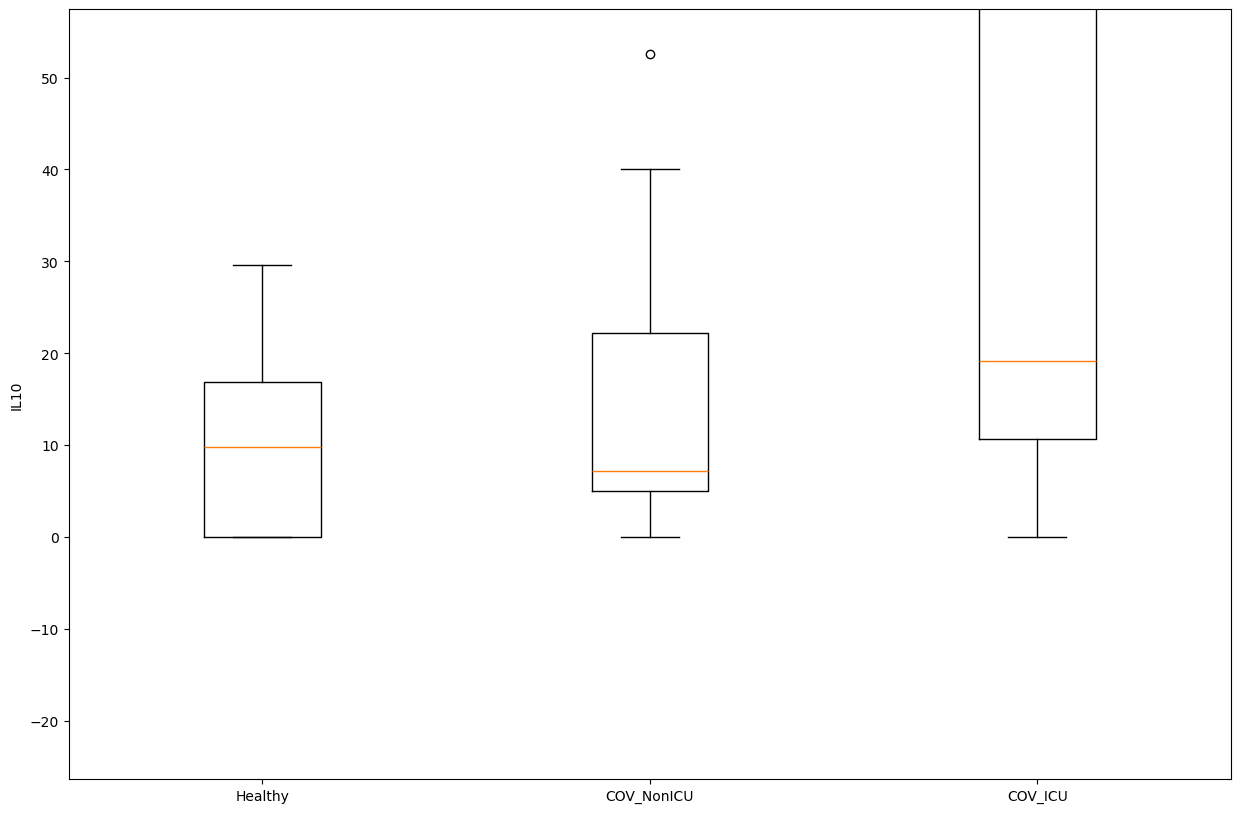

Results saved to IL10_result.png


In [15]:
# Import the module
import analyze

# Define the variables
omics_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/transcriptomics/transcriptomics_Su_2020_feature-data.csv'
samples_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/samples_dict.json'
feature = 'IL10'
output_file = 'IL10_result.png'

# Run the script
analyze.run_script(omics_file_url, samples_file_url, feature, output_file)


No valid samples found for group 'Healthy', skipping this group.


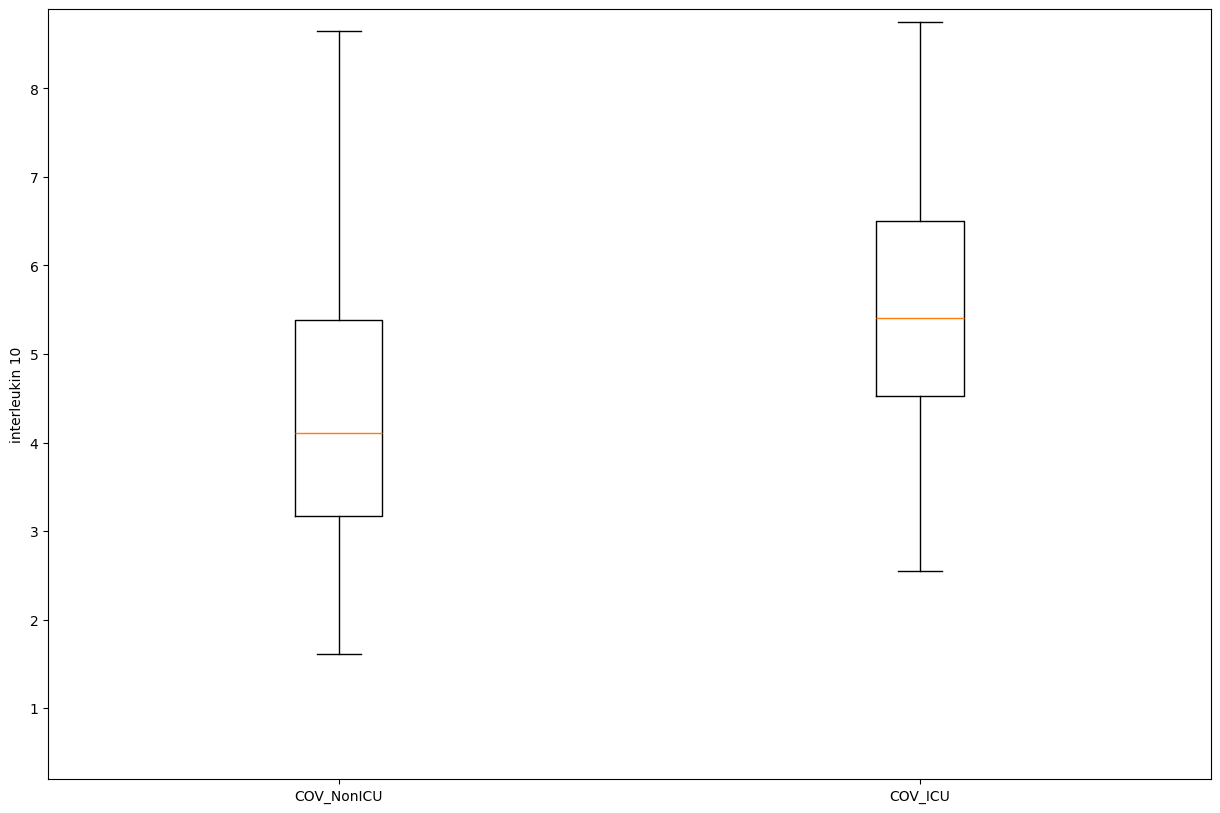

Results saved to interleukin 10_result.png


In [16]:
# Define the variables
omics_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/proteomics/proteomics_Su_2020_feature-data.csv'
samples_file_url = 'https://raw.githubusercontent.com/Xomics/TWOCdemonstrator/main/data/Su_2020_FAIR/samples_dict.json'
feature = 'interleukin 10'
output_file = 'interleukin 10_result.png'

# Run the script
analyze.run_script(omics_file_url, samples_file_url, feature, output_file)